### Instalamos librerías

In [ ]:

# !pip -q install cesium pyarrow
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.mixture import GaussianMixture
import warnings; warnings.filterwarnings("ignore")
import seaborn as sns
import pandas as pd
RNG = np.random.default_rng(42)


### Parámetros dataset sintético

In [ ]:

# Semilla y parámetros base
RNG = np.random.default_rng(42)

n_objects = 800              # número de objetos
bands = ["g", "r", "i", "z"] # bandas fotométricas (g-verde azulado / r-rojo / i-infrarrojo / z- infrarrojo más profundo)
t_min, t_max = 0, 120        # ventana temporal
min_points, max_points = 40, 120  # número de observaciones por banda/objeto son entre 40 y 120 en tiempos aleatorios



Definimos generador de curvas por clase

In [ ]:
def gen_curve(class_label, times):
    if class_label == 0:
        # Señal casi plana + ruido
        return RNG.normal(0, 1.0, size=len(times))
    elif class_label == 1:
        # Baja frecuencia
        f = RNG.uniform(0.03, 0.07)
        return 2*np.sin(2*np.pi*f*times + RNG.uniform(0, 2*np.pi)) + RNG.normal(0, 0.4, len(times))
    elif class_label == 2:
        # Alta frecuencia
        f = RNG.uniform(0.15, 0.35)
        return 1.2*np.sin(2*np.pi*f*times + RNG.uniform(0, 2*np.pi)) + RNG.normal(0, 0.4, len(times))
    else:
        # Tipo supernova
        center = RNG.uniform(30, 90)
        width  = RNG.uniform(5, 12)
        peak   = np.exp(-0.5*((times-center)/width)**2) * RNG.uniform(2.5, 4.0)
        return peak + RNG.normal(0, 0.35, len(times))


### Generación de dataframe

In [ ]:

rows = []

band_shift = dict(g=0.30, r=0.00, i=-0.20, z=-0.35)  # offsets por banda (desplazamiento vertical, color objeto)
band_scale = dict(g=1.00, r=1.00, i=0.90, z=0.80)    # escalas por banda (variación del brillo por banda)

for obj_id in range(n_objects):
    class_label = RNG.integers(0, 4)  # etiqueta de clase
    for b in bands:
        n_obs = RNG.integers(min_points, max_points)
        times = np.sort(RNG.uniform(t_min, t_max, size=n_obs))

        base  = gen_curve(class_label, times)
        flux  = band_scale[b] * base + band_shift[b]
        flux_err = RNG.uniform(0.05, 0.15, size=n_obs)       # incertidumbre
        meas  = flux + RNG.normal(0, flux_err)               # medición con ruido

        rows.extend((obj_id, b, t, y, e, class_label)
                    for t, y, e in zip(times, meas, flux_err))

df = pd.DataFrame(rows, columns=["obj_id","band","time","flux","flux_err","class_label"])
df["band"] = df["band"].astype("category")
df["class_label"] = df["class_label"].astype("int8")

df.head(), df.shape


(   obj_id band      time      flux  flux_err  class_label
 0       0    g  0.883472 -0.095444  0.072966            0
 1       0    g  2.725449  1.610381  0.063182            0
 2       0    g  3.698140 -0.021406  0.117766            0
 3       0    g  5.256452  1.014389  0.062183            0
 4       0    g  6.996329 -0.810402  0.100633            0,
 (254375, 6))

Graficar un objeto por bandas (chequeo)


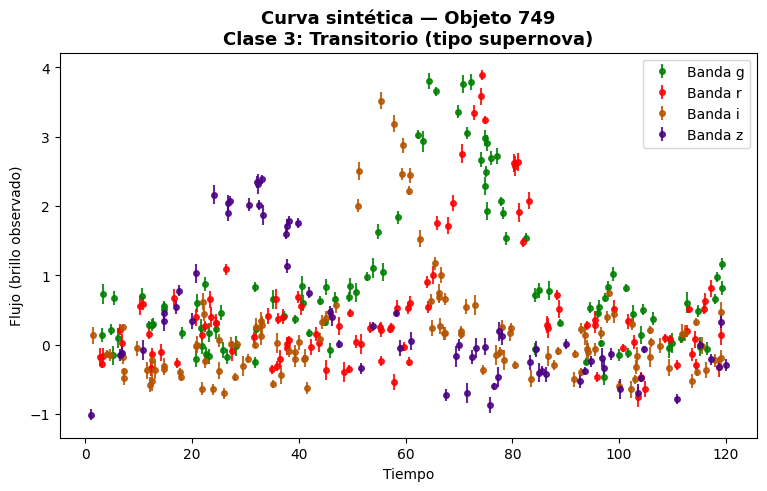

In [ ]:
# Diccionario que traduce los números de clase a nombres más explicativos
nombres_clases = {
    0: "Ruido / Señal plana",
    1: "Senoidal (frecuencia baja)",
    2: "Senoidal (frecuencia alta)",
    3: "Transitorio (tipo supernova)"
}

# Mapa de colores para las bandas fotométricas (coherente con la realidad)
band_colors = {
    "g": "green",       # verde
    "r": "red",         # rojo
    "i": "#b55400",     # naranja oscuro → infrarrojo cercano
    "z": "#4b0082"      # violeta oscuro → infrarrojo más profundo
}

# Seleccionamos un objeto aleatorio para visualizar
sample_id = int(df["obj_id"].sample(1, random_state=0).iloc[0])
df_s = df[df.obj_id == sample_id].copy()
class_id = int(df_s.class_label.iloc[0])

# Gráfico de la curva multibanda
plt.figure(figsize=(9,5))
for b in bands:
    sub = df_s[df_s.band == b]
    if len(sub) == 0:
        continue
    plt.errorbar(
        sub.time, sub.flux, yerr=sub.flux_err,
        fmt='o', ms=4, alpha=.85,
        color=band_colors[b],
        label=f"Banda {b}"
    )


plt.title(
    f"Curva sintética — Objeto {sample_id}\nClase {class_id}: {nombres_clases[class_id]}",
    fontsize=13, fontweight="bold"
)

plt.xlabel("Tiempo")
plt.ylabel("Flujo (brillo observado)")
plt.legend()
plt.show()


### Extracción de características

In [ ]:
from scipy.stats import skew, kurtosis

# Calcula estadísticas por grupo (objeto + banda)
def calcular_caracteristicas(grupo):
    y = grupo["flux"].values
    return pd.Series({
        "media": np.mean(y),
        "desviacion": np.std(y, ddof=1),
        "minimo": np.min(y),
        "maximo": np.max(y),
        "amplitud": np.max(y) - np.min(y),
        "asimetria": skew(y, bias=False),
        "curtosis": kurtosis(y, fisher=False, bias=False),
        "n_observaciones": len(y)
    })

# Se aplica la función a cada combinación (objeto, banda)
caract_banda = (
    df.groupby(["obj_id", "band"], observed=True)
      .apply(calcular_caracteristicas)
      .reset_index()
)

caract_banda.head()



,obj_id,band,media,desviacion,minimo,maximo,amplitud,asimetria,curtosis,n_observaciones
0,0,g,0.299646,0.977220,-1.893293,3.101744,4.995036,0.347546,2.833845,101.0
1,0,i,-0.219045,0.911644,-3.525916,1.997079,5.522995,-0.511429,4.060012,119.0
2,0,r,-0.098744,0.988200,-2.863516,2.352252,5.215769,-0.141470,3.137097,93.0
3,0,z,-0.415699,0.912464,-2.770786,1.826207,4.596993,-0.139098,3.357423,66.0
4,1,g,-0.023962,1.485400,-2.201115,2.757938,4.959053,0.309290,1.926116,73.0


Reorganización de la tabla:

*   Cada fila corresponderá a un solo objeto.
*   Cada columna contiene las características de cada banda.



In [ ]:
# Haremos una fila por objeto
caract_ancha = (
    caract_banda
    .pivot(index="obj_id", columns="band",
           values=["media", "desviacion", "amplitud", "asimetria", "curtosis", "n_observaciones"])
)

# Aplanamos los nombres por columnas
caract_ancha.columns = [f"{nombre}_{banda}" for nombre, banda in caract_ancha.columns.to_flat_index()]
caract_ancha = caract_ancha.reset_index()

# Agregamos la etiqueta (clase verdadera) a cada objeto
etiquetas = df[["obj_id", "class_label"]].drop_duplicates()
datos = caract_ancha.merge(etiquetas, on="obj_id", how="left").fillna(0)

datos.head()


,obj_id,media_g,media_i,media_r,media_z,desviacion_g,desviacion_i,desviacion_r,desviacion_z,amplitud_g,...,asimetria_z,curtosis_g,curtosis_i,curtosis_r,curtosis_z,n_observaciones_g,n_observaciones_i,n_observaciones_r,n_observaciones_z,class_label
0,0,0.299646,-0.219045,-0.098744,-0.415699,0.977220,0.911644,0.988200,0.912464,4.995036,...,-0.139098,2.833845,4.060012,3.137097,3.357423,101.0,119.0,93.0,66.0,0
1,1,-0.023962,-0.374625,-0.062743,-0.729249,1.485400,1.218219,1.526039,1.041929,4.959053,...,0.567504,1.926116,1.694363,1.508879,2.716612,73.0,42.0,78.0,47.0,1
2,2,0.373847,-0.242489,0.148366,-0.344234,1.011935,0.858607,0.898826,0.756236,3.793740,...,-0.015185,1.984978,1.954624,2.312196,1.914841,58.0,103.0,72.0,71.0,2
3,3,0.154527,-0.129674,-0.072259,-0.363717,1.517964,1.308943,1.509344,1.168235,4.932345,...,0.075961,1.496922,1.697244,1.575426,1.876346,41.0,61.0,114.0,81.0,1
4,4,0.847826,0.160220,0.622020,-0.010334,1.035872,0.919029,1.077044,0.711450,4.354085,...,1.377255,3.896474,5.475796,3.527963,4.753987,45.0,65.0,73.0,117.0,3


### División de datos (entrenamiento y prueba)

In [ ]:
# Variables independientes (X) y variable objetivo (y)
X = datos.drop(columns=["obj_id", "class_label"])
y = datos["class_label"]

# División 75% entrenamiento / 25% prueba
X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Tamaño entrenamiento:", X_entrenamiento.shape)
print("Tamaño prueba:", X_prueba.shape)




Tamaño entrenamiento: (600, 24)
Tamaño prueba: (200, 24)


## Matriz de confusión Random Forest

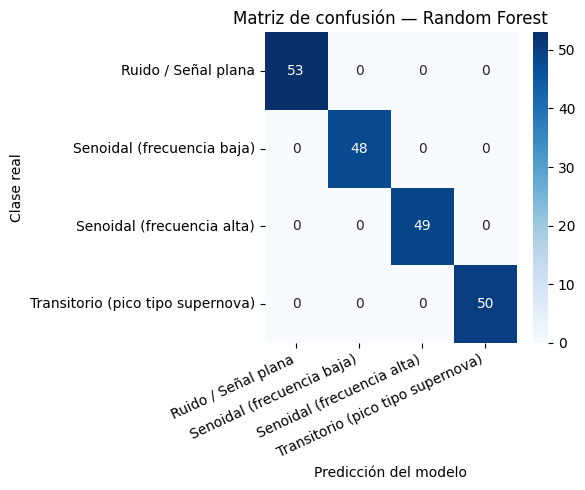

In [ ]:
# Calculamos la matriz de confusión
matriz = confusion_matrix(y_prueba, y_pred)

# Nombres de clases según tu simulación
nombres_clases = [
    "Ruido / Señal plana",
    "Senoidal (frecuencia baja)",
    "Senoidal (frecuencia alta)",
    "Transitorio (pico tipo supernova)"
]

# Gráfico
plt.figure(figsize=(6,5))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues",
            xticklabels=nombres_clases, yticklabels=nombres_clases)

plt.xlabel("Predicción del modelo")
plt.ylabel("Clase real")
plt.title("Matriz de confusión — Random Forest")
plt.xticks(rotation=25, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### MLP

Mejores hiperparámetros: {'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (128, 64), 'mlp__learning_rate_init': 0.001}
Score CV (f1_macro): 0.9934640522875817
F1_macro (test): 0.9752425212199813

Reporte de clasificación:
               precision    recall  f1-score   support

           0       1.00      0.91      0.95        53
           1       0.98      1.00      0.99        48
           2       0.92      1.00      0.96        49
           3       1.00      1.00      1.00        50

    accuracy                           0.97       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.97      0.97       200



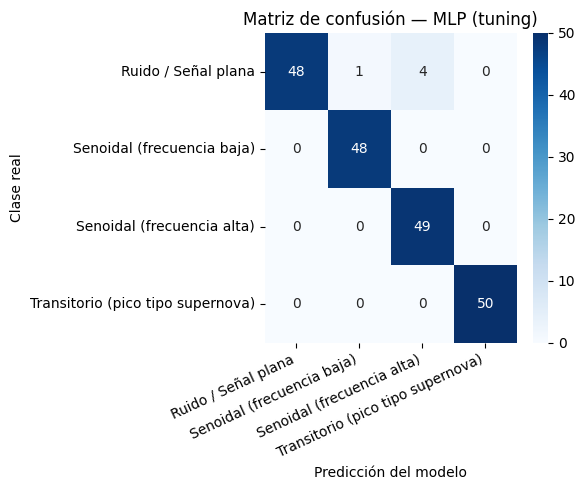

In [ ]:
# ====== Pipeline: escalar -> MLP ======
mlp_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(max_iter=400, random_state=42, early_stopping=True, n_iter_no_change=15))
])

# ====== Grid pequeña (rápida) ======
param_grid = {
    "mlp__hidden_layer_sizes": [(64,), (128,), (128,64)],
    "mlp__alpha": [1e-4, 1e-3, 1e-2],
    "mlp__learning_rate_init": [1e-3, 5e-4]
}

mlp_gs = GridSearchCV(
    estimator=mlp_pipe,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    verbose=0
)

mlp_gs.fit(X_entrenamiento, y_entrenamiento)

print("Mejores hiperparámetros:", mlp_gs.best_params_)
print("Score CV (f1_macro):", mlp_gs.best_score_)

# ====== Evaluación en el set de prueba ======
y_pred_mlp = mlp_gs.best_estimator_.predict(X_prueba)
print("F1_macro (test):", f1_score(y_prueba, y_pred_mlp, average="macro"))
print("\nReporte de clasificación:\n", classification_report(y_prueba, y_pred_mlp))

# Matriz de confusión
matriz = confusion_matrix(y_prueba, y_pred_mlp)
nombres_clases = [
    "Ruido / Señal plana",
    "Senoidal (frecuencia baja)",
    "Senoidal (frecuencia alta)",
    "Transitorio (pico tipo supernova)"
]

plt.figure(figsize=(6,5))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues",
            xticklabels=nombres_clases, yticklabels=nombres_clases)
plt.xlabel("Predicción del modelo")
plt.ylabel("Clase real")
plt.title("Matriz de confusión — MLP (tuning)")
plt.xticks(rotation=25, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



Utilizamos dos capas cn 128 y 64 neuronas cada una.




### GMM

Asumimos distribuciones normales gaussianas

F1_macro (test): 0.975297878523685

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.91      1.00      0.95        53
           1       1.00      1.00      1.00        48
           2       1.00      0.90      0.95        49
           3       1.00      1.00      1.00        50

    accuracy                           0.97       200
   macro avg       0.98      0.97      0.98       200
weighted avg       0.98      0.97      0.97       200



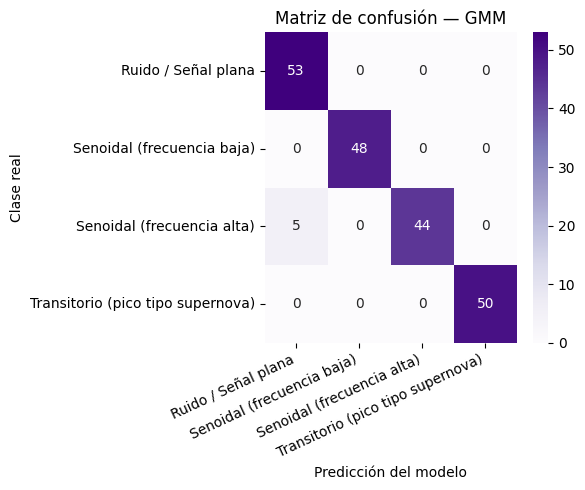

In [ ]:
# ====== Entrenamos un GMM para cada clase ======
gmm_models = {}
n_componentes = 2  # cada clase puede tener 2 subgrupos internos

for clase in np.unique(y_entrenamiento):
    gmm = GaussianMixture(
        n_components=n_componentes,
        covariance_type='full',
        random_state=42
    )
    gmm.fit(X_entrenamiento[y_entrenamiento == clase])
    gmm_models[clase] = gmm

# ====== Clasificamos cada muestra del set de prueba ======
log_likelihoods = np.zeros((len(X_prueba), len(gmm_models)))

for i, clase in enumerate(gmm_models.keys()):
    log_likelihoods[:, i] = gmm_models[clase].score_samples(X_prueba)

y_pred_gmm = np.argmax(log_likelihoods, axis=1)

# ====== Métricas de evaluación ======
print("F1_macro (test):", f1_score(y_prueba, y_pred_gmm, average="macro"))
print("\nReporte de clasificación:\n", classification_report(y_prueba, y_pred_gmm))

# ====== Matriz de confusión ======
matriz = confusion_matrix(y_prueba, y_pred_gmm)
nombres_clases = [
    "Ruido / Señal plana",
    "Senoidal (frecuencia baja)",
    "Senoidal (frecuencia alta)",
    "Transitorio (pico tipo supernova)"
]

plt.figure(figsize=(6,5))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Purples",
            xticklabels=nombres_clases, yticklabels=nombres_clases)
plt.xlabel("Predicción del modelo")
plt.ylabel("Clase real")
plt.title("Matriz de confusión — GMM")
plt.xticks(rotation=25, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### **Comparación de resultados**

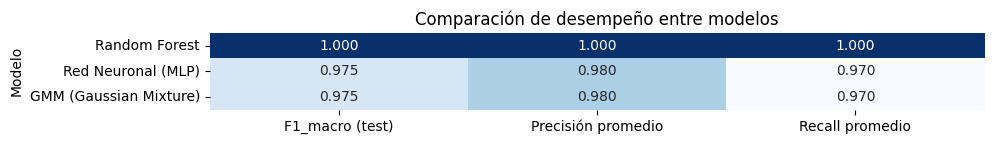

,Modelo,Tipo de modelo,F1_macro (test),Precisión promedio,Recall promedio,Comentarios
0,Random Forest,Supervisado basado en árboles,1.000,1.00,1.00,Rendimiento perfecto; alto poder explicativo e...
1,Red Neuronal (MLP),Supervisado no lineal (red neuronal),0.975,0.98,0.97,Excelente generalización; captura relaciones n...
2,GMM (Gaussian Mixture),Probabilístico basado en densidades,0.975,0.98,0.97,Gran desempeño; ofrece interpretación probabil...


In [ ]:


# ==== Datos obtenidos ====
resultados = {
    "Modelo": ["Random Forest", "Red Neuronal (MLP)", "GMM (Gaussian Mixture)"],
    "Tipo de modelo": [
        "Supervisado basado en árboles",
        "Supervisado no lineal (red neuronal)",
        "Probabilístico basado en densidades"
    ],
    "F1_macro (test)": [1.00, 0.975, 0.975],
    "Precisión promedio": [1.00, 0.98, 0.98],
    "Recall promedio": [1.00, 0.97, 0.97],
    "Comentarios": [
        "Rendimiento perfecto; alto poder explicativo e interpretabilidad.",
        "Excelente generalización; captura relaciones no lineales complejas.",
        "Gran desempeño; ofrece interpretación probabilística e incertidumbre."
    ]
}

tabla_resultados = pd.DataFrame(resultados)

# ==== Mostrar tabla ====
plt.figure(figsize=(10,1))
sns.heatmap(
    tabla_resultados.set_index("Modelo")[["F1_macro (test)", "Precisión promedio", "Recall promedio"]],
    annot=True, cmap="Blues", fmt=".3f", cbar=False
)
plt.title("Comparación de desempeño entre modelos")
plt.yticks(rotation=0)
plt.show()

# ==== Tabla textual ====
tabla_resultados


### Entrenamiento con Random Forest

In [ ]:
# Creamos el modelo
bosque = RandomForestClassifier(
    n_estimators=300,   # número de árboles
    max_depth=None,     # sin límite de profundidad
    random_state=42,
    n_jobs=-1           # usa todos los núcleos disponibles
)

# Entrenamos el modelo
bosque.fit(X_entrenamiento, y_entrenamiento)

# Predicciones
y_pred = bosque.predict(X_prueba)

# Métricas de evaluación
print("F1_macro:", f1_score(y_prueba, y_pred, average="macro"))
print("\nReporte de clasificación:")
print(classification_report(y_prueba, y_pred))

print("\nMatriz de confusión:")
print(confusion_matrix(y_prueba, y_pred))


F1_macro: 1.0

Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       1.00      1.00      1.00        48
           2       1.00      1.00      1.00        49
           3       1.00      1.00      1.00        50

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


Matriz de confusión:
[[53  0  0  0]
 [ 0 48  0  0]
 [ 0  0 49  0]
 [ 0  0  0 50]]


### Trabajo PLAsTiCC

In [ ]:
# === Cargar archivos PLAsTiCC ===
meta = pd.read_csv("plasticc_train_metadata.csv")
lc = pd.read_csv("plasticc_train_lightcurves.csv")
targets = pd.read_csv("plasticc_train_target_names.csv")

print("Metadata:", meta.shape)
print("Lightcurves:", lc.shape)
print("Targets:", targets.shape)

# === Ver primeras filas ===
display(meta.head())
display(lc.head())
display(targets.head())

# === Unir información de nombre de clase ===
meta = meta.merge(targets, how="left", on="target")
display(meta.head(3))




Metadata: (7848, 26)
Lightcurves: (1421705, 6)
Targets: (18, 2)


,object_id,ra,decl,ddf_bool,hostgal_specz,hostgal_photoz,hostgal_photoz_err,distmod,mwebv,target,...,true_rv,true_av,true_peakmjd,libid_cadence,tflux_u,tflux_g,tflux_r,tflux_i,tflux_z,tflux_y
0,615,349.0461,-61.9438,1,0.000,0.000,0.000,-9.000,0.017,92,...,0.0,0.0,59570.000,69,484.7,3286.7,3214.1,3039.7,2854.5,2837.0
1,713,53.0859,-27.7844,1,1.818,1.627,0.255,45.406,0.007,88,...,0.0,0.0,59570.000,34,108.7,117.7,119.9,149.6,147.9,150.5
2,730,33.5742,-6.5796,1,0.232,0.226,0.016,40.256,0.021,42,...,0.0,0.0,60444.379,9,0.0,0.0,0.0,0.0,0.0,0.0
3,745,0.1899,-45.5867,1,0.304,0.281,1.152,40.795,0.007,90,...,0.0,0.0,60130.453,38,0.0,0.0,0.0,0.0,0.0,0.0
4,1124,352.7113,-63.8237,1,0.193,0.241,0.018,40.417,0.024,90,...,0.0,0.0,60452.641,1,0.0,0.0,0.0,0.0,0.0,0.0


,object_id,mjd,passband,flux,flux_err,detected_bool
0,615,59750.4229,2,-544.810303,3.622952,1
1,615,59750.4306,1,-816.434326,5.553370,1
2,615,59750.4383,3,-471.385529,3.801213,1
3,615,59750.4450,4,-388.984985,11.395031,1
4,615,59752.4070,2,-681.858887,4.041204,1


,target,type
0,6,uLens-Single_GenLens
1,15,TDE
2,16,EB
3,42,SNIIn
4,52,SNIax


,object_id,ra,decl,ddf_bool,hostgal_specz,hostgal_photoz,hostgal_photoz_err,distmod,mwebv,target,...,true_av,true_peakmjd,libid_cadence,tflux_u,tflux_g,tflux_r,tflux_i,tflux_z,tflux_y,type
0,615,349.0461,-61.9438,1,0.000,0.000,0.000,-9.000,0.017,92,...,0.0,59570.000,69,484.7,3286.7,3214.1,3039.7,2854.5,2837.0,RRL
1,713,53.0859,-27.7844,1,1.818,1.627,0.255,45.406,0.007,88,...,0.0,59570.000,34,108.7,117.7,119.9,149.6,147.9,150.5,AGN
2,730,33.5742,-6.5796,1,0.232,0.226,0.016,40.256,0.021,42,...,0.0,60444.379,9,0.0,0.0,0.0,0.0,0.0,0.0,SNIIn


### Subconjunto de datos para trabajar preeliminarmente

In [ ]:
# --- Función para limpiar nombres de columnas: quita espacios y pasa a minúsculas ---
def limpiar_cols(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.replace('\ufeff', '', regex=True)  # elimina caracteres invisibles (BOM)
        .str.strip()                             # quita espacios
        .str.lower()                             # convierte a minúsculas
    )
    return df


# --- Limpieza de columnas en los tres DataFrames ---
meta = limpiar_cols(meta)
lc = limpiar_cols(lc)
targets = limpiar_cols(targets)

print("Cols meta:", list(meta.columns)[:10], "...", len(meta.columns))
print("Cols targets:", list(targets.columns))


# --- Verifica que 'type' esté disponible en targets ---
if "type" not in targets.columns:
    posibles = [c for c in targets.columns if "type" in c]
    raise KeyError(f"No encuentro columna 'type' en targets. Candidatas: {posibles}")


# --- Elimina 'type' en meta si ya existe para evitar conflicto en el merge ---
if "type" in meta.columns:
    meta = meta.drop(columns=["type"])


# --- Une meta + targets para incorporar el nombre humano de la clase ---
meta = meta.merge(targets[["target", "type"]], on="target", how="left")

print("Merge completado. Columnas actuales:", list(meta.columns)[:15])


Cols meta: ['object_id', 'ra', 'decl', 'ddf_bool', 'hostgal_specz', 'hostgal_photoz', 'hostgal_photoz_err', 'distmod', 'mwebv', 'target'] ... 29
Cols targets: ['target', 'type']
Merge completado. Columnas actuales: ['object_id', 'ra', 'decl', 'ddf_bool', 'hostgal_specz', 'hostgal_photoz', 'hostgal_photoz_err', 'distmod', 'mwebv', 'target', 'true_target', 'true_submodel', 'true_z', 'true_distmod', 'true_lensdmu']


### Limpiamos dataset para utilizar modelos hechos con anterioridad

In [ ]:
# Conteo por clase
conteo = df_feat["target"].value_counts().sort_values(ascending=False)
print(conteo)

# Nos quedamos las TOP 5 clases
TOP_K = 5
clases_validas = conteo.head(TOP_K).index



df_sub = df_feat[df_feat["target"].isin(clases_validas)].copy()



if "type" in df_sub.columns:
    # Renombramos para etiquetar
    df_sub["tipo"] = df_sub["type"]
else:
    df_sub["tipo"] = df_sub["target"].astype(str)

print("Clases usadas:", df_sub["target"].nunique())
df_sub["target"].value_counts()


target
90    73
42    51
65    45
16    41
62    18
88    17
15    17
92    10
95     8
52     8
67     4
6      4
64     3
53     1
Name: count, dtype: int64
Clases usadas: 5


,count
target,
90,73
42,51
65,45
16,41
62,18


Realizamos la división

In [ ]:
X = df_sub[["flux_mean", "flux_std", "flux_amp", "flux_skew", "flux_kurt"]]
y = df_sub["target"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Entrenamiento:", X_train.shape, " | Prueba:", X_test.shape)
y_train.value_counts(), y_test.value_counts()


Entrenamiento: (182, 5)  | Prueba: (46, 5)


(target
 90    58
 42    41
 65    36
 16    33
 62    14
 Name: count, dtype: int64,
 target
 90    15
 42    10
 65     9
 16     8
 62     4
 Name: count, dtype: int64)

### Entrenamos y evaluamos con Random Forest

              precision    recall  f1-score   support

          16       0.86      0.75      0.80         8
          42       0.50      0.70      0.58        10
          62       0.00      0.00      0.00         4
          65       0.70      0.78      0.74         9
          90       0.53      0.53      0.53        15

    accuracy                           0.61        46
   macro avg       0.52      0.55      0.53        46
weighted avg       0.57      0.61      0.58        46



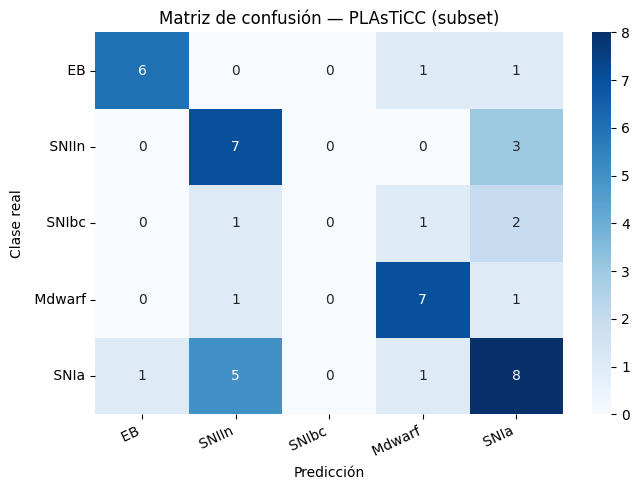

In [ ]:
rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred, labels=sorted(y_test.unique()))

# Etiquetas legibles para la matriz (si tienes nombres en 'tipo'):
map_target_to_tipo = df_sub.drop_duplicates("target").set_index("target")["tipo"].to_dict()
tick_labels = [map_target_to_tipo[t] for t in sorted(y_test.unique())]

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=tick_labels, yticklabels=tick_labels)
plt.xlabel("Predicción"); plt.ylabel("Clase real")
plt.title("Matriz de confusión — PLAsTiCC (subset)")
plt.xticks(rotation=25, ha="right"); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()


### MLP

In [ ]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    learning_rate_init=0.001,
    alpha=0.0001,
    max_iter=1000,
    random_state=42
)

mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

print("🔹 MLP — F1_macro:", f1_score(y_test, y_pred_mlp, average="macro"))
print(classification_report(y_test, y_pred_mlp))


🔹 MLP — F1_macro: 0.3266214177978884
              precision    recall  f1-score   support

          16       0.56      0.62      0.59         8
          42       0.00      0.00      0.00        10
          62       0.00      0.00      0.00         4
          65       0.75      0.33      0.46         9
          90       0.42      0.93      0.58        15

    accuracy                           0.48        46
   macro avg       0.35      0.38      0.33        46
weighted avg       0.38      0.48      0.38        46



### GMM

In [ ]:
# Entrenamos GMM suponiendo que hay tantas clases como targets distintos
n_classes = len(np.unique(y_train))
gmm = GaussianMixture(n_components=n_classes, random_state=42)
gmm.fit(X_train)

# Asignamos cada muestra al cluster más probable
y_pred_gmm = gmm.predict(X_test)

# Para evaluar, igualamos los clusters con etiquetas reales mediante mapeo óptimo
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_gmm)
row_ind, col_ind = linear_sum_assignment(-cm)
mapping = {col: row for row, col in zip(row_ind, col_ind)}

y_pred_gmm_mapped = np.array([mapping[c] if c in mapping else -1 for c in y_pred_gmm])

print("🔹 GMM — F1_macro:", f1_score(y_test, y_pred_gmm_mapped, average="macro"))
print(classification_report(y_test, y_pred_gmm_mapped))


🔹 GMM — F1_macro: 0.0
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
           1       0.00      0.00      0.00       0.0
           3       0.00      0.00      0.00       0.0
          16       0.00      0.00      0.00       8.0
          42       0.00      0.00      0.00      10.0
          62       0.00      0.00      0.00       4.0
          65       0.00      0.00      0.00       9.0
          90       0.00      0.00      0.00      15.0

    accuracy                           0.00      46.0
   macro avg       0.00      0.00      0.00      46.0
weighted avg       0.00      0.00      0.00      46.0



### Comparativa de los modelos

In [ ]:
# Tabla comparativa de desempeño de modelos
data = {
    "Modelo": ["Random Forest", "MLP (Red Neuronal)", "GMM (Gaussian Mixture)"],
    "Precision (avg)": [0.57, 0.38, 0.00],
    "Recall (avg)": [0.61, 0.48, 0.00],
    "F1_macro": [0.53, 0.33, 0.00],
    "Accuracy": [0.61, 0.48, 0.00],
}

tabla_resultados = pd.DataFrame(data)
display(tabla_resultados)

,Modelo,Precision (avg),Recall (avg),F1_macro,Accuracy
0,Random Forest,0.57,0.61,0.53,0.61
1,MLP (Red Neuronal),0.38,0.48,0.33,0.48
2,GMM (Gaussian Mixture),0.00,0.00,0.00,0.00


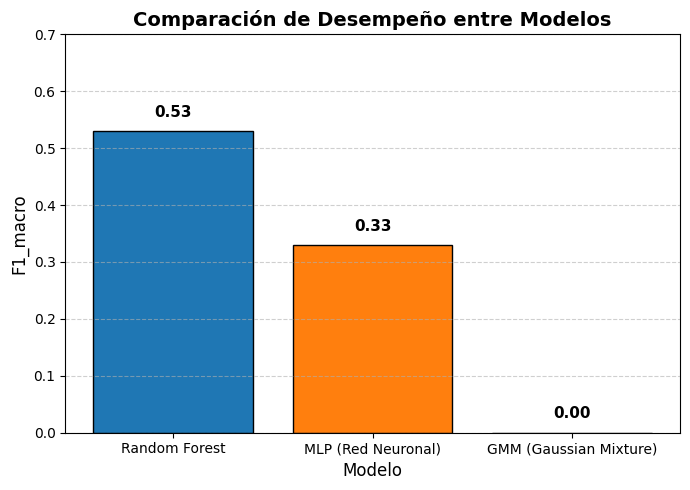

In [ ]:
# Datos de desempeño
data = {
    "Modelo": ["Random Forest", "MLP (Red Neuronal)", "GMM (Gaussian Mixture)"],
    "F1_macro": [0.53, 0.33, 0.00],
}

df_scores = pd.DataFrame(data)

# Colores
colores = ["#1f77b4", "#ff7f0e", "#d62728"]  # azul, naranja, rojo

# Gráficos
plt.figure(figsize=(7,5))
barras = plt.bar(df_scores["Modelo"], df_scores["F1_macro"], color=colores, edgecolor='black')

# Etiquetas de valores arriba de cada barra
for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, altura + 0.02, f"{altura:.2f}",
             ha='center', va='bottom', fontsize=11, fontweight='bold')


plt.title("Comparación de Desempeño entre Modelos", fontsize=14, fontweight='bold')
plt.ylabel("F1_macro", fontsize=12)
plt.xlabel("Modelo", fontsize=12)
plt.ylim(0, 0.7)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
